In [15]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('../')

import pm4py
from pm4py.objects.petri_net.importer import importer as pnml_importer
from pm4py.objects.log.importer.xes import importer as xes_importer
from pm4py.convert import convert_to_bpmn
from pm4py.visualization.bpmn import visualizer as bpmn_visualizer

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
sys.path.insert(0, r"C:\Users\safaya\Documents\GitHub\da4py")
import da4py
from da4py.main.conformanceChecking.conformanceArtefacts import ConformanceArtefacts

In [17]:
PNML_DIR = "../data/processed/BPIC/pnml/BPIC12.xes.gz.2.heuristic.pnml"
LOG_DIR = "../data/processed/BPIC/xes/BPIC12.xes.gz.2.heuristic.xes.gz"

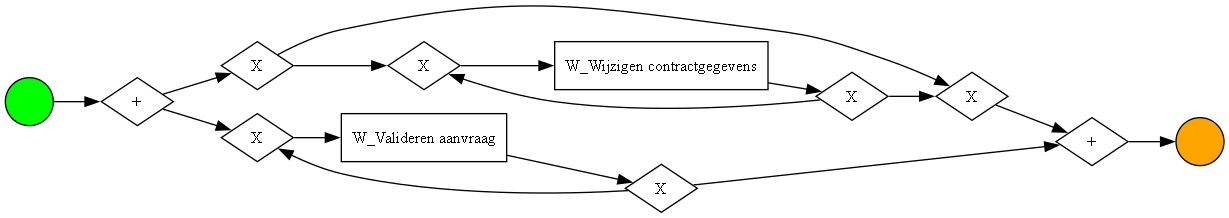

In [18]:
try:
    net, m0, mf = pnml_importer.apply(PNML_DIR)
    bpmn_model = convert_to_bpmn(net, m0, mf)
    gviz = bpmn_visualizer.apply(bpmn_model)
    bpmn_visualizer.view(gviz)
    
except Exception as e:
    print(f"  Error loading file paths")

In [19]:
log = xes_importer.apply(LOG_DIR)
print(f"Number of traces: {len(log)}")
print(f"Length of first trace: {len(log[0])}")
print(f"First trace case attributes: {log[0].attributes}")
print("First event:", log[0][0])

parsing log, completed traces ::   0%|          | 0/3254 [00:00<?, ?it/s]

Number of traces: 3254
Length of first trace: 3
First trace case attributes: {'REG_DATE': datetime.datetime(2011, 10, 1, 0, 38, 44, 546000, tzinfo=datetime.timezone.utc), 'concept:name': '173688', 'AMOUNT_REQ': '20000'}
First event: {'org:resource': '11049', 'lifecycle:transition': 'SCHEDULE', 'concept:name': 'W_Valideren aanvraag', 'time:timestamp': datetime.datetime(2011, 10, 10, 11, 33, 4, 560000, tzinfo=datetime.timezone.utc)}


In [20]:
# Filter log to unique trace variants before alignment
from pm4py.objects.log.obj import EventLog

variants = pm4py.get_variants(log)
print(f"Original traces: {len(log)}")
print(f"Unique trace variants: {len(variants)}")

unique_log = EventLog()
for variant_traces in variants.values():
    unique_log.append(variant_traces[0])

print(f"Unique traces in filtered log: {len(unique_log)}")
log = unique_log

Original traces: 3254
Unique trace variants: 42
Unique traces in filtered log: 42


In [23]:
# 2. Create anti-alignment object
artefacts = ConformanceArtefacts()

'''
size_of_run limits how long the candidate execution can be.
max_d limits how different that execution is allowed to be from the log.
'''

artefacts.setDistance_type("edit")    # "edit" or "hamming"
artefacts.setSize_of_run(10)          # length of anti-alignment to find
artefacts.setMax_d(10)                # max distance to try (for perf)
artefacts.setSilentLabel("None")     # optional: label that costs nothing

# 3. Compute anti-alignment
artefacts.antiAlignment(net, m0, mf, log)

# 4. Get results
print("Anti-alignment run:", artefacts.getRun())
print("Trace distances:", artefacts.getTracesWithDistances())
print("Precision:", artefacts.getPrecision())
print("Min distance to run:", artefacts.getMinDistanceToRun())

Anti-alignment run: [None, None, 'W_Wijzigen contractgegevens', 'W_Valideren aanvraag', None, None, 'W_Valideren aanvraag', None, 'W_Wijzigen contractgegevens', 'W_Valideren aanvraag']
Trace distances:     distance                                             traces
0          4  [W_Valideren aanvraag, W_Valideren aanvraag, W...
1          6  [W_Valideren aanvraag, W_Valideren aanvraag, W...
2          3  [W_Valideren aanvraag, W_Valideren aanvraag, W...
3          8  [W_Valideren aanvraag, W_Valideren aanvraag, W...
4         15  [W_Valideren aanvraag, W_Valideren aanvraag, W...
5          5  [W_Valideren aanvraag, W_Valideren aanvraag, W...
6          7  [W_Valideren aanvraag, W_Valideren aanvraag, W...
7         17  [W_Valideren aanvraag, W_Valideren aanvraag, W...
8          4  [W_Valideren aanvraag, W_Valideren aanvraag, W...
9         13  [W_Valideren aanvraag, W_Valideren aanvraag, W...
10        27  [W_Valideren aanvraag, W_Valideren aanvraag, W...
11         9  [W_Valideren aan